---
format:
  html:
    code-fold: true
    code-summary: "Mostrar código"
---

# El balance de materia

En cualquier empresa quesera, con independencia de su tamaño, una de las primeras y más básicas cosas a realizar es un análisis del balance global de la elaboración quesera. Para un período determinado, que como primera aproximación, puede ser anual, se trata de conocer el balance entre la leche comprada y el queso producido, tanto en materia grasa como en proteína. Dado que toda la materia que no esté en el queso no puede ser vendida, no recuperaremos el coste de materia de las pérdidas (el suero de quesería ya no es un ingreso por venta; en la actualidad, en la mayor parte de los casos el suero es recogido a valor cero por las empresas que se encargan del secado de suero, con el valor del transporte como elemento de negociación).

En nuestro ejemplo, los datos que vamos a utilizar están registrados en ficheros de datos en formato `CSV`, que incluyen las entradas de leche en fábrica, los movimientos de leche dentro de la fábrica hasta su envío a fabricación, y las analíticas de la leche y el queso, así como alguna analítica adicional del proceso.

Analizaremos el conjunto de datos con `python`y Excel, siguiendo nuestra línea de trabajo.

## Caso de una fabricación sencilla de un tipo de leche

 Comenzaremos con el caso más simple, en el que se utiliza un solo tipo de leche, que no se estandariza en MG ni en MP, y se envía a fabricación después de pasteurización.

In [1]:
#| echo: false

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

url_datos = (
    "https://raw.githubusercontent.com/"
    "juanriera/master-queseria/master/"
    "datos/fab_queso_sim.csv"
)

try:
    df = pd.read_csv(url_datos, decimal = ",", sep=';', encoding='ISO-8859-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

Verificamos los datos que hemos leído imprimiendo las primeras líneas del CSV

In [2]:
df.head()

,fecha,dia_semana,semana,entrada_kg,entrada_litros,entrada_grasa_g_l,entrada_prot_g_l,envio_fab_litros,envio_fab_grasa_g_l,envio_fab_prot_g_l,ratio_perdida_mg,ratio_perdida_mp,ratio_inc_agua,stock_cierre_litros
0,31/12/2023,Domingo,1,5290,5136,35.34,31.98,0,0.00,0.00,0.00000,0.00000,0.00000,5136
1,01/01/2024,Lunes,1,5672,5507,38.29,33.03,4700,34.91,30.85,0.04798,0.04633,0.00538,5968
2,02/01/2024,Martes,1,5130,4981,40.27,30.88,4539,36.69,30.36,0.04080,0.04017,0.00444,6430
3,03/01/2024,Miércoles,1,5109,4960,37.70,31.51,5165,36.36,30.38,0.04100,0.03548,0.00499,6251
4,04/01/2024,Jueves,1,5149,4999,37.58,33.21,5398,36.09,30.92,0.04201,0.03928,0.00517,5880


Verificamos la información del dataframe

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fecha                175 non-null    object 
 1   dia_semana           175 non-null    object 
 2   semana               175 non-null    int64  
 3   entrada_kg           175 non-null    int64  
 4   entrada_litros       175 non-null    int64  
 5   entrada_grasa_g_l    175 non-null    float64
 6   entrada_prot_g_l     175 non-null    float64
 7   envio_fab_litros     175 non-null    int64  
 8   envio_fab_grasa_g_l  175 non-null    float64
 9   envio_fab_prot_g_l   175 non-null    float64
 10  ratio_perdida_mg     175 non-null    float64
 11  ratio_perdida_mp     175 non-null    float64
 12  ratio_inc_agua       175 non-null    float64
 13  stock_cierre_litros  175 non-null    int64  
dtypes: float64(7), int64(5), object(2)
memory usage: 19.3+ KB
None


Por conveniencia, vamos a añadir un campo índice con las fechas, y ordenamos el dataframe por fecha.

In [4]:
# crear index con fecha
df['fecha_index'] = pd.to_datetime(
    df['fecha'], 
    format='%d/%m/%Y',  # Formato Día/Mes/Año confirmado
    errors='coerce'     # Clave: convierte los valores que no puede leer a NaT (Not a Time)
)
# 2. Limpiar NaT y establecer el índice
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

El fichero CSV de datos incluye la fecha del movimiento, el peso de báscula de la cisterna de esntrada, y diversas analíticas, entre las que están la composición en MG y MP y otras analíticas de calidad. Para hacer el balance de materia estamos interesados en saber el total de MG y de MP que ha entrado en fábrica en el período en que vamos a realizar el cálculo el BM. Como las analíticas de MG y MP son masa/volumen (g por 100 ml de leche), necesitamos la densidad para calcular el total de materia en los kilos que hemos dado de entrada.

Por comodidad, para evitar errores de medida y de muestreo (desigual reparto de la MG), la fábrica utiliza la densidad estándar de 1,030 g/100 ml de leche, que aplicamos a todos los cálculos. 

In [5]:
df['entrada_mg_kg'] =  df['entrada_litros'] * df['entrada_grasa_g_l']/1000
df['entrada_mp_kg'] =  df['entrada_litros'] * df['entrada_prot_g_l']/1000

In [6]:
df.head()

,fecha,dia_semana,semana,entrada_kg,entrada_litros,entrada_grasa_g_l,entrada_prot_g_l,envio_fab_litros,envio_fab_grasa_g_l,envio_fab_prot_g_l,ratio_perdida_mg,ratio_perdida_mp,ratio_inc_agua,stock_cierre_litros,entrada_mg_kg,entrada_mp_kg
fecha_index,,,,,,,,,,,,,,,,
2023-12-31,31/12/2023,Domingo,1,5290,5136,35.34,31.98,0,0.00,0.00,0.00000,0.00000,0.00000,5136,181.50624,164.24928
2024-01-01,01/01/2024,Lunes,1,5672,5507,38.29,33.03,4700,34.91,30.85,0.04798,0.04633,0.00538,5968,210.86303,181.89621
2024-01-02,02/01/2024,Martes,1,5130,4981,40.27,30.88,4539,36.69,30.36,0.04080,0.04017,0.00444,6430,200.58487,153.81328
2024-01-03,03/01/2024,Miércoles,1,5109,4960,37.70,31.51,5165,36.36,30.38,0.04100,0.03548,0.00499,6251,186.99200,156.28960
2024-01-04,04/01/2024,Jueves,1,5149,4999,37.58,33.21,5398,36.09,30.92,0.04201,0.03928,0.00517,5880,187.86242,166.01679


Como las existencias de leche quedan siempre a cero en fin de semana (los viernes), podemos totalizar las entradas en fábrica por semanas, para comparar con los envíos a fabricación y hacer el balance de materia correspondiente.

In [7]:
# Convertir la columna fecha a datetime
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True)

# 2. Agrupación limpia
# Seleccionamos solo las columnas de interés y las numéricas 
# para evitar que concatene los nombres de los días
df_semanal = (
    df.drop(columns=['dia_semana']) # Eliminamos la columna que estorba
    .resample('W-SUN', on='fecha', closed='left', label='left')
    .sum()
)

print(df_semanal.head())

            semana  entrada_kg  entrada_litros  entrada_grasa_g_l  \
fecha                                                               
2023-12-31       7       26350           25583             189.18   
2024-01-07      14       26380           25611             187.58   
2024-01-14      21       26352           25585             179.81   
2024-01-21      28       26772           25993             182.59   
2024-01-28      35       25903           25149             184.16   

            entrada_prot_g_l  envio_fab_litros  envio_fab_grasa_g_l  \
fecha                                                                 
2023-12-31            160.61             25708               180.26   
2024-01-07            160.09             25734               179.31   
2024-01-14            161.07             25730               172.25   
2024-01-21            157.54             26146               174.27   
2024-01-28            159.19             25266               175.52   

            envio_

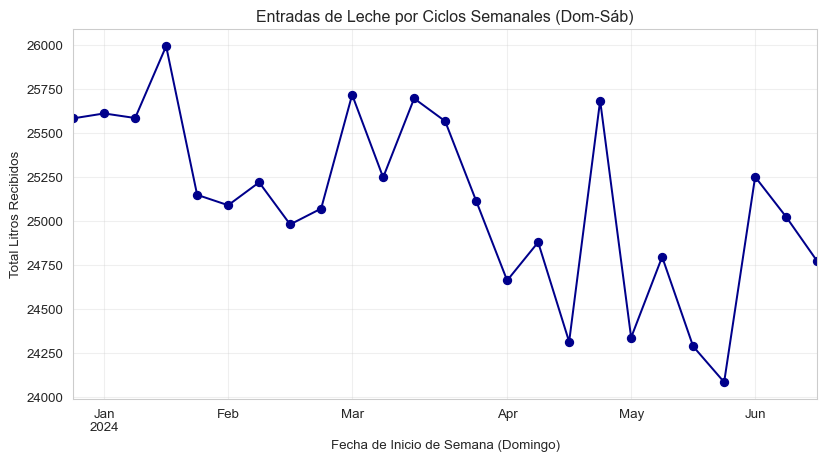

In [8]:
# Visualización
plt.figure(figsize=(10, 4))

df_semanal['entrada_litros'].plot(kind='line', marker='o', figsize=(10, 5), color='darkblue')
plt.title('Entradas de Leche por Ciclos Semanales (Dom-Sáb)')
plt.xlabel('Fecha de Inicio de Semana (Domingo)')
plt.ylabel('Total Litros Recibidos')
plt.grid(True, alpha=0.3)
plt.show()

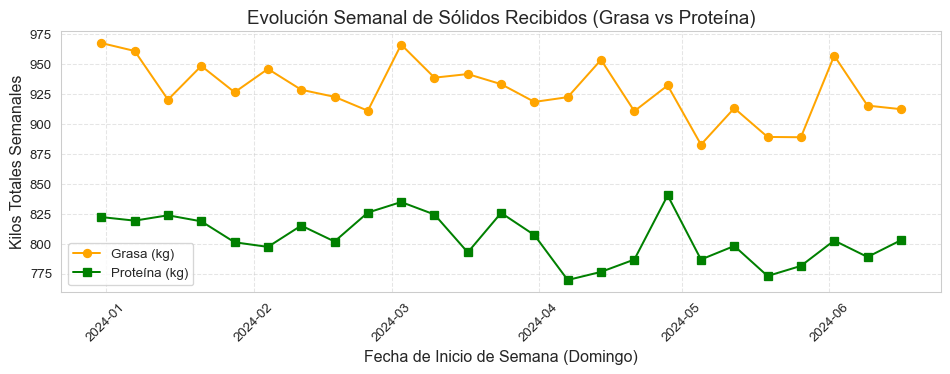

In [9]:
# Visualización de las dos líneas
plt.figure(figsize=(10, 4))

# Graficamos ambas columnas
plt.plot(df_semanal.index, df_semanal['entrada_mg_kg'], marker='o', color='orange', label='Grasa (kg)')
plt.plot(df_semanal.index, df_semanal['entrada_mp_kg'], marker='s', color='green', label='Proteína (kg)')

# Configuración del gráfico
plt.title('Evolución Semanal de Sólidos Recibidos (Grasa vs Proteína)', fontsize=14)
plt.xlabel('Fecha de Inicio de Semana (Domingo)', fontsize=12)
plt.ylabel('Kilos Totales Semanales', fontsize=12)
plt.legend() # Muestra la leyenda para distinguir las líneas
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Código sin verificar, ATENCION, uso de nuevo df

In [10]:
url_datos = (
    "https://raw.githubusercontent.com/"
    "juanriera/master-queseria/master/"
    "datos/fab_queso_bm.csv"
)

try:
    df = pd.read_csv(url_datos, decimal = ",", sep=';', encoding='ISO-8859-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

# crear index con fecha
df['fecha_index'] = pd.to_datetime(
    df['fecha'], 
    format='%d/%m/%Y',  # Formato Día/Mes/Año confirmado
    errors='coerce'     # Clave: convierte los valores que no puede leer a NaT (Not a Time)
)
# 2. Limpiar NaT y establecer el índice
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

In [11]:
df['mg_kg_past'] = df['litros_past']*df['mg_past']/100
df['mp_kg_past'] = df['litros_past']*df['mp_past']/100

df[['litros_past', 'mg_kg_past', 'mp_kg_past']].resample('W-MON').sum()

,litros_past,mg_kg_past,mp_kg_past
fecha_index,,,
2022-02-28,19860,704.62400,745.42200
2022-03-07,68715,3045.80910,2641.96190
2022-03-14,46570,2242.75700,1985.34100
2022-03-21,52310,2892.21600,2270.18600
2022-03-28,12633,491.29737,425.98476
2022-04-04,28110,924.21780,940.33740
2022-04-11,40488,1667.95420,1563.44480
2022-04-18,37227,1396.31290,1378.71500
2022-04-25,38040,1604.53190,1491.38340




En una fábrica en la que se elabora más de un producto, y se utilizan varios tipos de leche y otras materias primas, es conveniente separar en varias partes los movimientos de entrada e internos, para facilitar el análisis posterior.

 el fichero de datos de fabricación debe parecerse a éste, en el que se detallan los volúmenes y analíticas tanto de la leche enviada a fabricación como de los quesos elaborados. Caracterizaremos nuestro queso mediante un análisis de extracto seco total (EST) y una grasa butirométrica (MG), en un punto determinado de nuestro proceso (por ejemplo, a la salida de la salmuera, después de escurrido) y mediante un muestreo repetible, de forma que nuestro análisis sea representativo. A partir de estos dos análisis, calculamos otros parámetros técnicos necesarios, tales como la materia grasa sobre el extracto seco total (G/ES), el extracto seco magro o desnatado (ESM) y la humedad del queso desnatado (HQD), valores que se calculan a partir de los primeros.

In [12]:
# Agrupar y sumar
resumen = df.groupby('receta')[['litros_past', 'peso_queso_total']].sum()

# Calcular la relación litros/kilo
resumen['litros_por_kilo'] = resumen['litros_past']/ resumen['peso_queso_total']

# Estimación del balance global
resumen['balance_kilos'] = resumen['peso_queso_total']-(resumen['litros_past']*1.030)

# Estimación del % de suero producido
resumen['suero_estimado_%'] = (resumen['balance_kilos']/1.020)/resumen['litros_past']*100

# Mostrar la tabla resultante
print(resumen)

         litros_past  peso_queso_total  litros_por_kilo  balance_kilos  \
receta                                                                   
bajo mg       132870           15005.8         8.854576     -121850.30   
i+D            59600            6763.0         8.812657      -54625.00   
mezcla        135400           21628.7         6.260201     -117833.30   
oveja         117920           21614.0         5.455723      -99843.60   
vaca          129333           15814.0         8.178386     -117398.99   

         suero_estimado_%  
receta                     
bajo mg        -89.908240  
i+D            -89.855573  
mezcla         -85.319677  
oveja          -83.010416  
vaca           -88.992793  


---

Dado que nuestros valores analíticos están expresados en porcentaje en peso, calculamos las cantidades de materia como se indica a continuación:

In [13]:
#| code-fold: false

### 1. Cálculos de Entradas
df['est_kg_cuba'] = df['kg_cuba'] * df['est_cuba'] / 100
df['mg_kg_cuba'] = df['kg_cuba'] * df['mg_cuba'] / 100
df['mp_kg_cuba'] = df['kg_cuba'] * df['mp_cuba'] / 100
df['esm_kg_cuba'] = df['est_kg_cuba'] - df['mg_kg_cuba'] 

### 2. Cálculos de Salidas
df['est_kg_queso'] = df['peso_queso_total'] * df['est_salida_salmuera'] / 100
df['mg_kg_queso'] = df['peso_queso_total'] * df['mg_salida_salmuera'] / 100
df['esm_kg_queso'] = df['est_kg_queso'] - df['mg_kg_queso']
df['sal_kg_queso'] = df['peso_queso_total'] * df['sal_queso']/100

### 3. Coeficientes de recuperación (expresado en porcentaje)
df['coef_recup_mg']  = df['mg_kg_queso']/df['mg_kg_cuba'] * 100
df['coef_recup_mp']  = df['esm_kg_queso']/df['mp_kg_cuba'] * 100 # atencion a la fórmula de cálculo, deberia ser mp_kg_queso
df['coef_recup_esm'] = df['esm_kg_queso']/df['esm_kg_cuba'] * 100

### 4. Consumos de materia por kilo de queso (expresado en gramos de materia por kilo de queso)
df['consumo_mg_kg'] = df['mg_kg_cuba'] / df['peso_queso_total'] * 1000
df['consumo_mp_kg'] = df['mp_kg_cuba'] / df['peso_queso_total'] * 1000

### 5. Balance de Materia (Salida - Entrada)
# La falta de producto queda como negativo al hacer Salida - Entrada
df['balance_est'] = df['est_kg_queso'] - df['est_kg_cuba']
df['balance_mg'] = df['mg_kg_queso'] - df['mg_kg_cuba']
df['balance_esm'] = df['esm_kg_queso'] - df['esm_kg_cuba'] - df['sal_kg_queso']


In [14]:
### 6. Preparación y Exportación del DataFrame de Resultados
# Columnas finales a incluir en el reporte
columnas_balance = [
    'fecha', 'receta', 'formato',
    'litros_past', 'peso_queso_total',
    'est_kg_cuba', 'est_kg_queso', 
    'mg_kg_cuba', 'mg_kg_queso', 'mp_kg_cuba',
    'esm_kg_cuba', 'esm_kg_queso', 
    'coef_recup_mg', 'coef_recup_mp', 'coef_recup_esm',
    'consumo_mg_kg', 'consumo_mp_kg',
    'balance_est', 'balance_mg', 'balance_esm'
]

# Crear un nuevo DataFrame con las columnas de interés
df_balance = df[columnas_balance].copy()

# Guardar el DataFrame con punto decimal y separador ';'
nombre_archivo_salida = 'datos/informe_balance_materia.csv'
df_balance.to_csv(
    nombre_archivo_salida, 
    sep=';', 
    index=False,
    decimal=','
)


Ahora vamos a crear un nuevo `csv`con el balance de materia semanal, aprovechando las funciones de `pandas`para crear una columna de semana ISO.

In [15]:
# 1. Crear la columna 'semana' usando el formato ISO (Lunes=Día 1)
# Usamos el índice del DataFrame (que debe ser DatetimeIndex)
df['semana_iso'] = df.index.strftime('%G-W%V') 

print("✅ Columna 'semana_iso' creada con el estándar Lunes-Domingo.")

✅ Columna 'semana_iso' creada con el estándar Lunes-Domingo.


In [16]:
# Columnas que queremos sumarizar (Balances + Entradas + Salidas)
columnas_a_sumarizar = [
    # Entradas
    'est_kg_cuba', 'mg_kg_cuba', 'esm_kg_cuba',
    # Salidas
    'est_kg_queso', 'mg_kg_queso', 'esm_kg_queso',
    # Balances
    'balance_est', 'balance_mg', 'balance_esm'
]

# 2. Agrupar por 'semana_iso' y 'receta' y calcular la SUMA de todas las columnas
df_balance_semanal_completo = df.groupby(['semana_iso', 'balance_mg'])[columnas_a_sumarizar].sum()

# Renombrar las columnas para indicar que son totales
df_balance_semanal_completo.columns = [f'total_{col}' for col in columnas_a_sumarizar]

In [17]:
# 1. Definir el nombre del archivo de salida
nombre_archivo_final = 'datos/reporte_balance_completo_semanal_iso.csv'

# 2. Exportar el DataFrame a CSV
df_balance_semanal_completo.to_csv(
    nombre_archivo_final, 
    sep=';',        # Usa punto y coma como separador de columnas
    index=True,     # Mantiene las columnas de agrupación ('semana_iso' y 'receta')
    decimal=','     # Usa coma como separador decimal
)

In [18]:
df_sns  = df_balance_semanal_completo.reset_index(drop=False) # False mantiene la columna index como columna normal

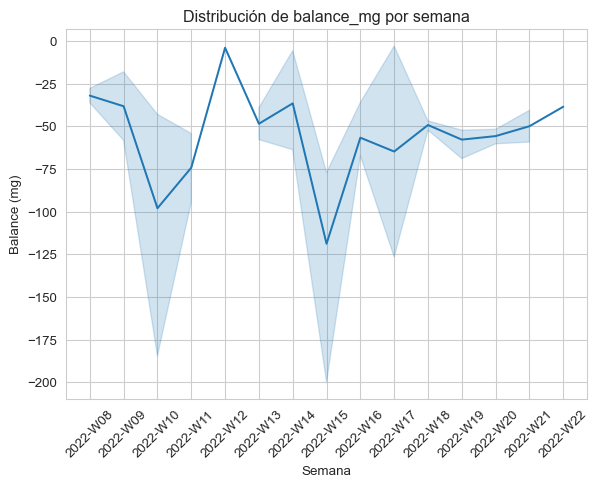

In [19]:
sns.lineplot(x='semana_iso', y='balance_mg', data=df_sns)

# Opcional: mejorar la visualización
plt.title('Distribución de balance_mg por semana')
plt.xlabel('Semana')
plt.ylabel('Balance (mg)')
plt.xticks(rotation=45)  # Si los nombres de semana son largos
plt.show()

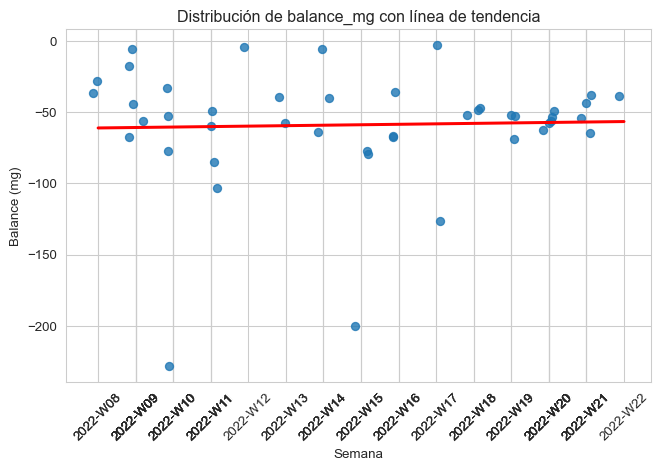

In [20]:

# Convertir semana_iso a números temporales
df_sns['semana_num'] = pd.factorize(df_sns['semana_iso'])[0]

# Dibujar la línea de tendencia con regplot
sns.regplot(
    x='semana_num',
    y='balance_mg',
    data=df_sns,
    scatter=True,
    x_jitter=0.2,     # añade jitter horizontal
    y_jitter=0.2,     # añade jitter vertical
    ci=None,
    line_kws={'color': 'red'},
)

# Reemplazar los ticks del eje X con las etiquetas originales
plt.xticks(
    ticks=df_sns['semana_num'],
    labels=df_sns['semana_iso'],
    rotation=45
)

# Mejorar visualización
plt.title('Distribución de balance_mg con línea de tendencia')
plt.xlabel('Semana')
plt.ylabel('Balance (mg)')
plt.tight_layout()
plt.show()


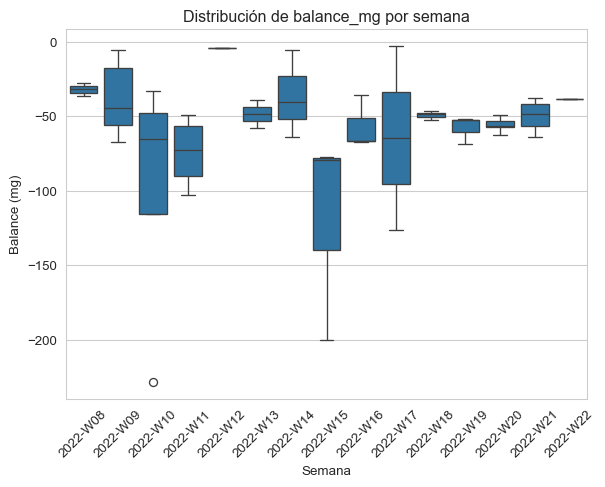

In [21]:
# Crear el boxplot
sns.boxplot(x='semana_iso', y='balance_mg', data=df_sns)

# Opcional: mejorar la visualización
plt.title('Distribución de balance_mg por semana')
plt.xlabel('Semana')
plt.ylabel('Balance (mg)')
plt.xticks(rotation=45)  # Si los nombres de semana son largos

plt.show()
